In [1]:
from fastscape.models import basic_model
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
%load_ext xsimlab.ipython

# Notebook 2
How to make a parameter (here the uplift rate) vary with time

In [2]:
# %create_setup basic_model -v -d
import xsimlab as xs

tf = 5e6
nstep = 101
ds_in = xs.create_setup(
    model=basic_model,
    clocks={'time':np.linspace(0,tf,nstep)},
    input_vars={
        # nb. of grid nodes in (y, x)
        'grid__shape':[101,201],
        # total grid length in (y, x)
        'grid__length':[10e3,20e3],
        # node status at borders
        'boundary__status': 'fixed_value',
        # uplift rate
        'uplift__rate': 1e-3, 
        # bedrock channel incision coefficient
        'spl__k_coef': 1e-5,
        # drainage area exponent
        'spl__area_exp': 0.45,
        # slope exponent
        'spl__slope_exp': 1,
        # diffusivity (transport coefficient)
        'diffusion__diffusivity':0.1 ,
        # random seed
        'init_topography__seed': None,
    },
    output_vars={'topography__elevation':'time',
                 'drainage__area':'time'}
)


We can create a time dependent function (here the uplift rate) from ds_in.time

In [3]:
xr.where(ds_in.time<2.5e6, 1e-3, 2e-3)

<xarray.DataArray 'time' (time: 101)>
array([0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002])
Coordinates:
  * time     (time) float64 0.0 5e+04 1e+05 1.5e+05 ... 4.9e+06 4.95e+06 5e+06

We run a model with this new definition for uplift__rate

In [4]:
import xarray as xr
with basic_model, xs.monitoring.ProgressBar():
    ds_out = (ds_in
              .xsimlab.update_vars(input_vars={'uplift__rate': xr.where(ds_in.time<2.5e6, 1e-3, 2e-3)})
              .xsimlab.run())

             0% | initialize 

This is what the mean topographic elevation looks like as a function of time

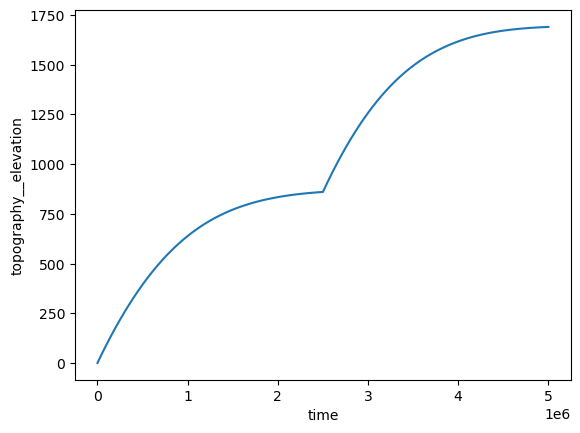

In [5]:
ds_out.topography__elevation.mean(('x','y')).plot();

We can llok at the plan form evolution of the topography. Note how we have selected only a small number of time steps for display. This oculd have been done by using a separate output clock (as done last week)

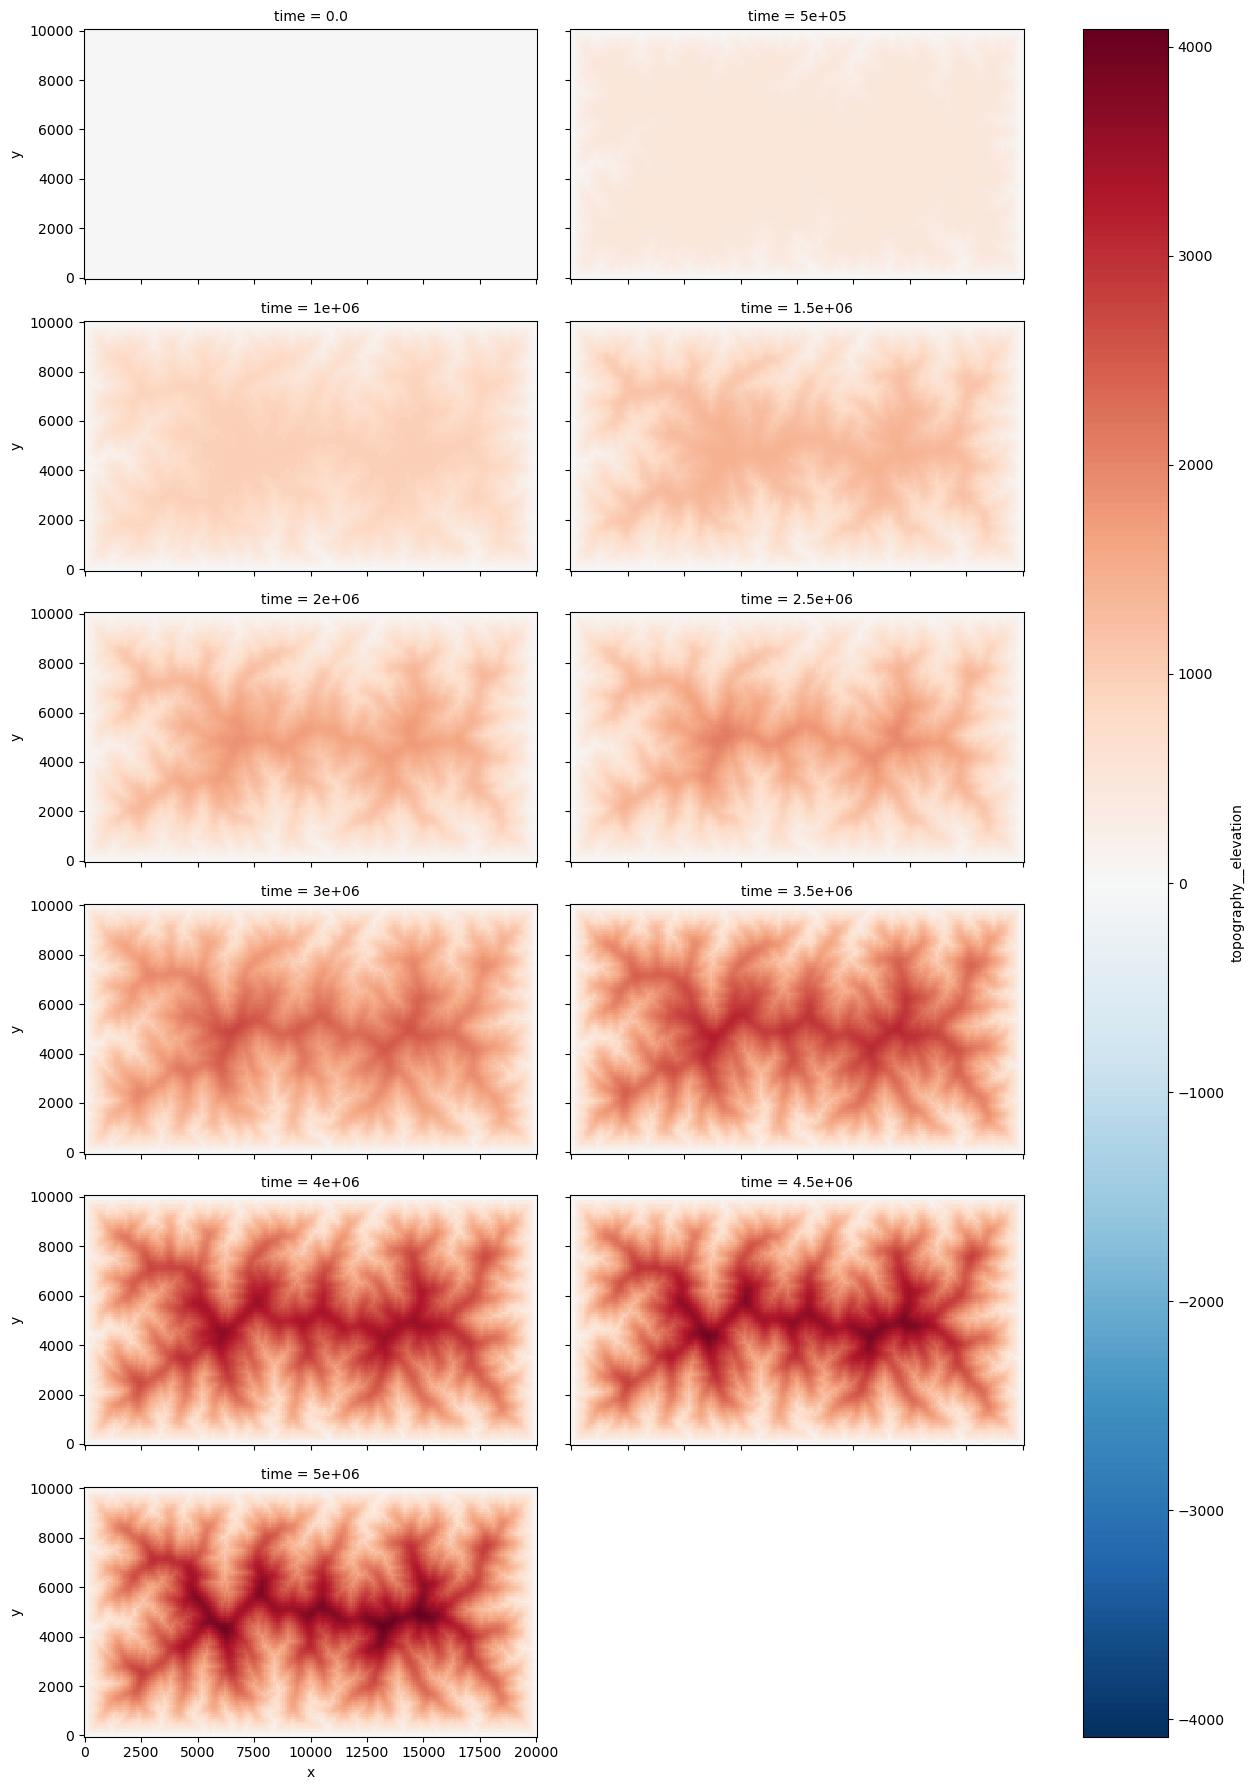

In [6]:
ds_out.topography__elevation.sel(time=ds_out.time[::10]).plot(col='time', col_wrap=2, aspect=2);

We can ask to have the erosion rate output

In [7]:
import xarray as xr
with basic_model, xs.monitoring.ProgressBar():
    ds_out = (ds_in
              .xsimlab.update_vars(input_vars={'uplift__rate': xr.where(ds_in.time<2e6, 1e-3, 2e-3)},
                                   output_vars={'erosion__rate':'time'})
              .xsimlab.run())

             0% | initialize 

And we can plot it along the drainage network, i.e., by restricting th eplotting to areas having a discharge larger thatn a given threshold (1/100 th of the maximum discharge)

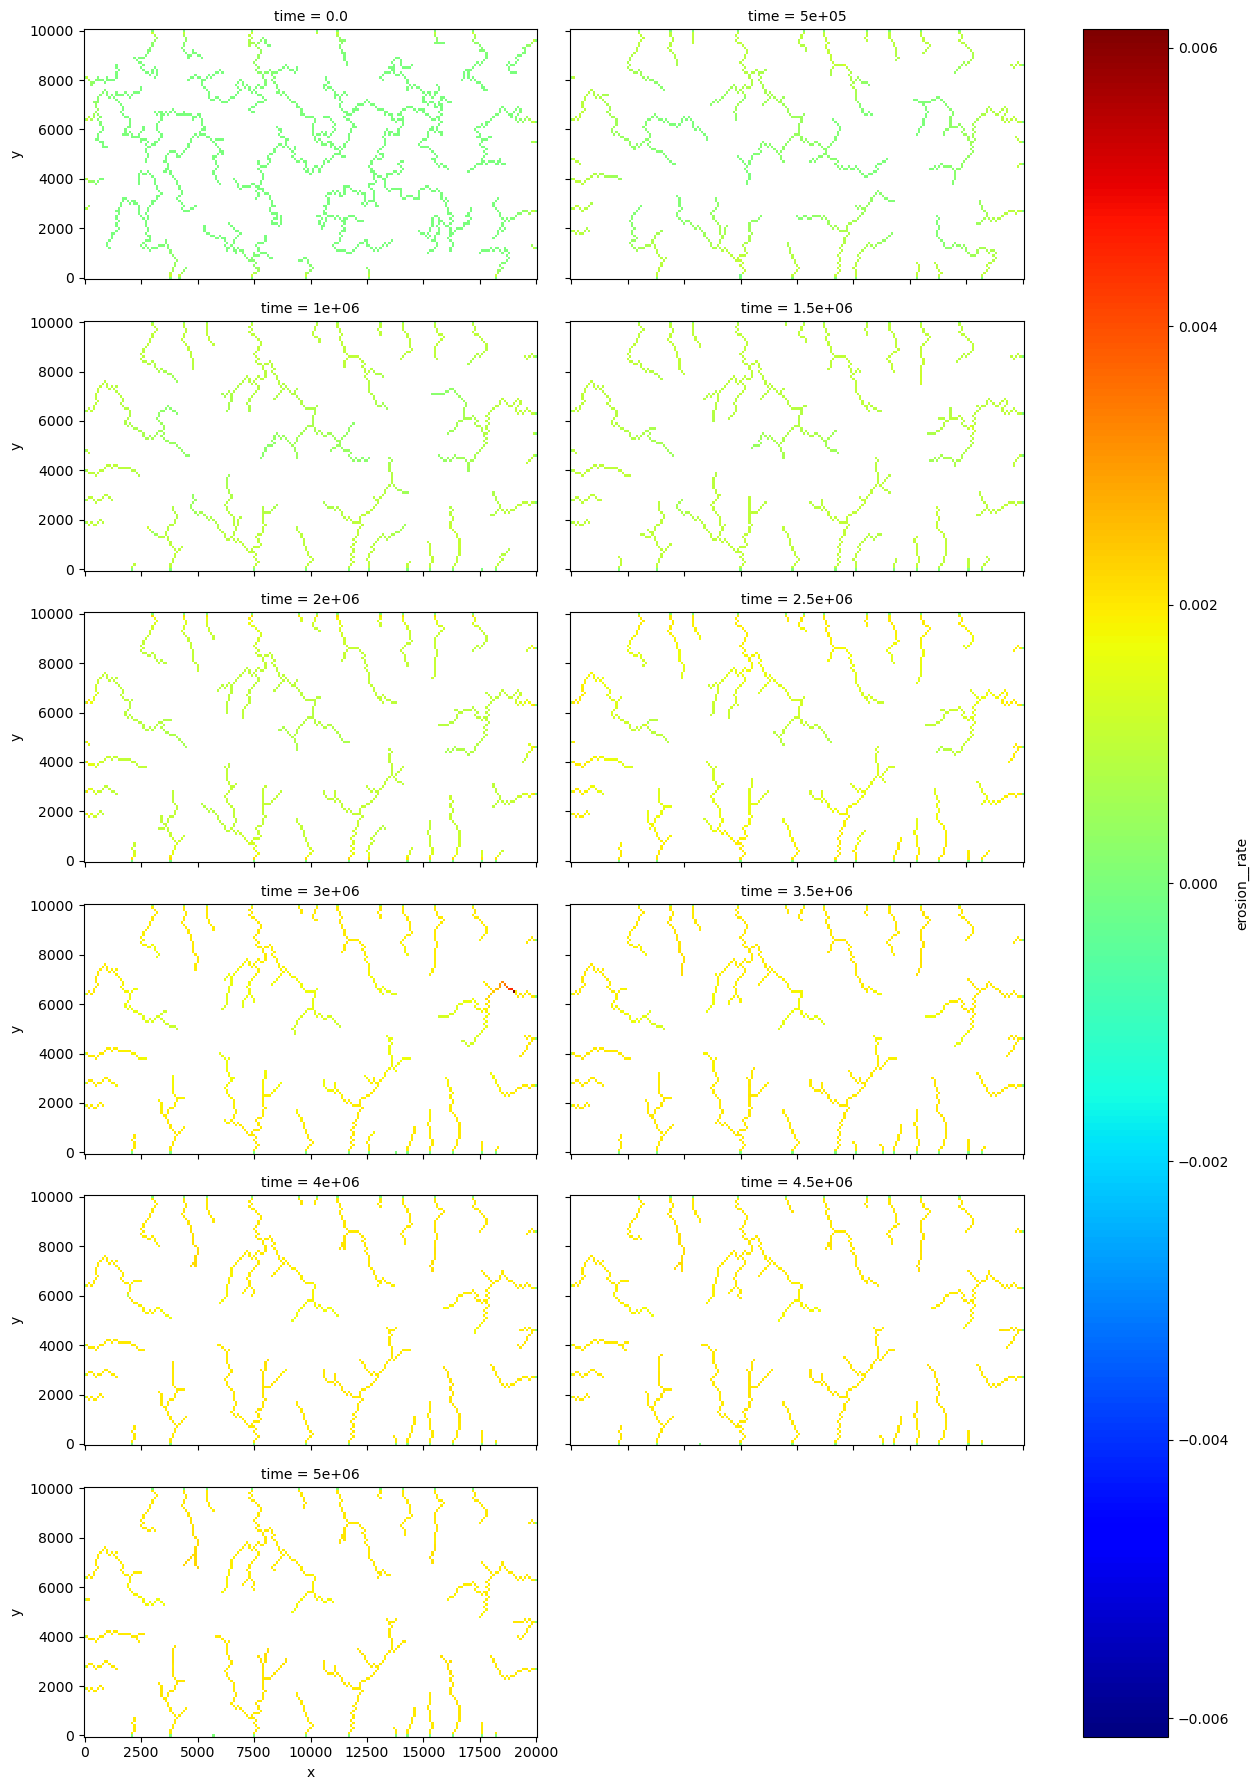

In [8]:
(ds_out.erosion__rate
 .where(ds_out.drainage__area>ds_out.drainage__area.max()/100)
 .sel(time=ds_out.time[::10])
 .plot(col='time', col_wrap=2, aspect=2, cmap='jet')
 )

Finally we do the smae for the slope using the `terrain` process which computes slope, curvature, etc

In [9]:
import xarray as xr
with basic_model, xs.monitoring.ProgressBar():
    ds_out = (ds_in
              .xsimlab.update_vars(input_vars={'uplift__rate': xr.where(ds_in.time<2e6, 1e-3, 2e-3)},
                                   output_vars={'erosion__rate':'time',
                                                'terrain__slope':'time'})
              .xsimlab.run())

             0% | initialize 

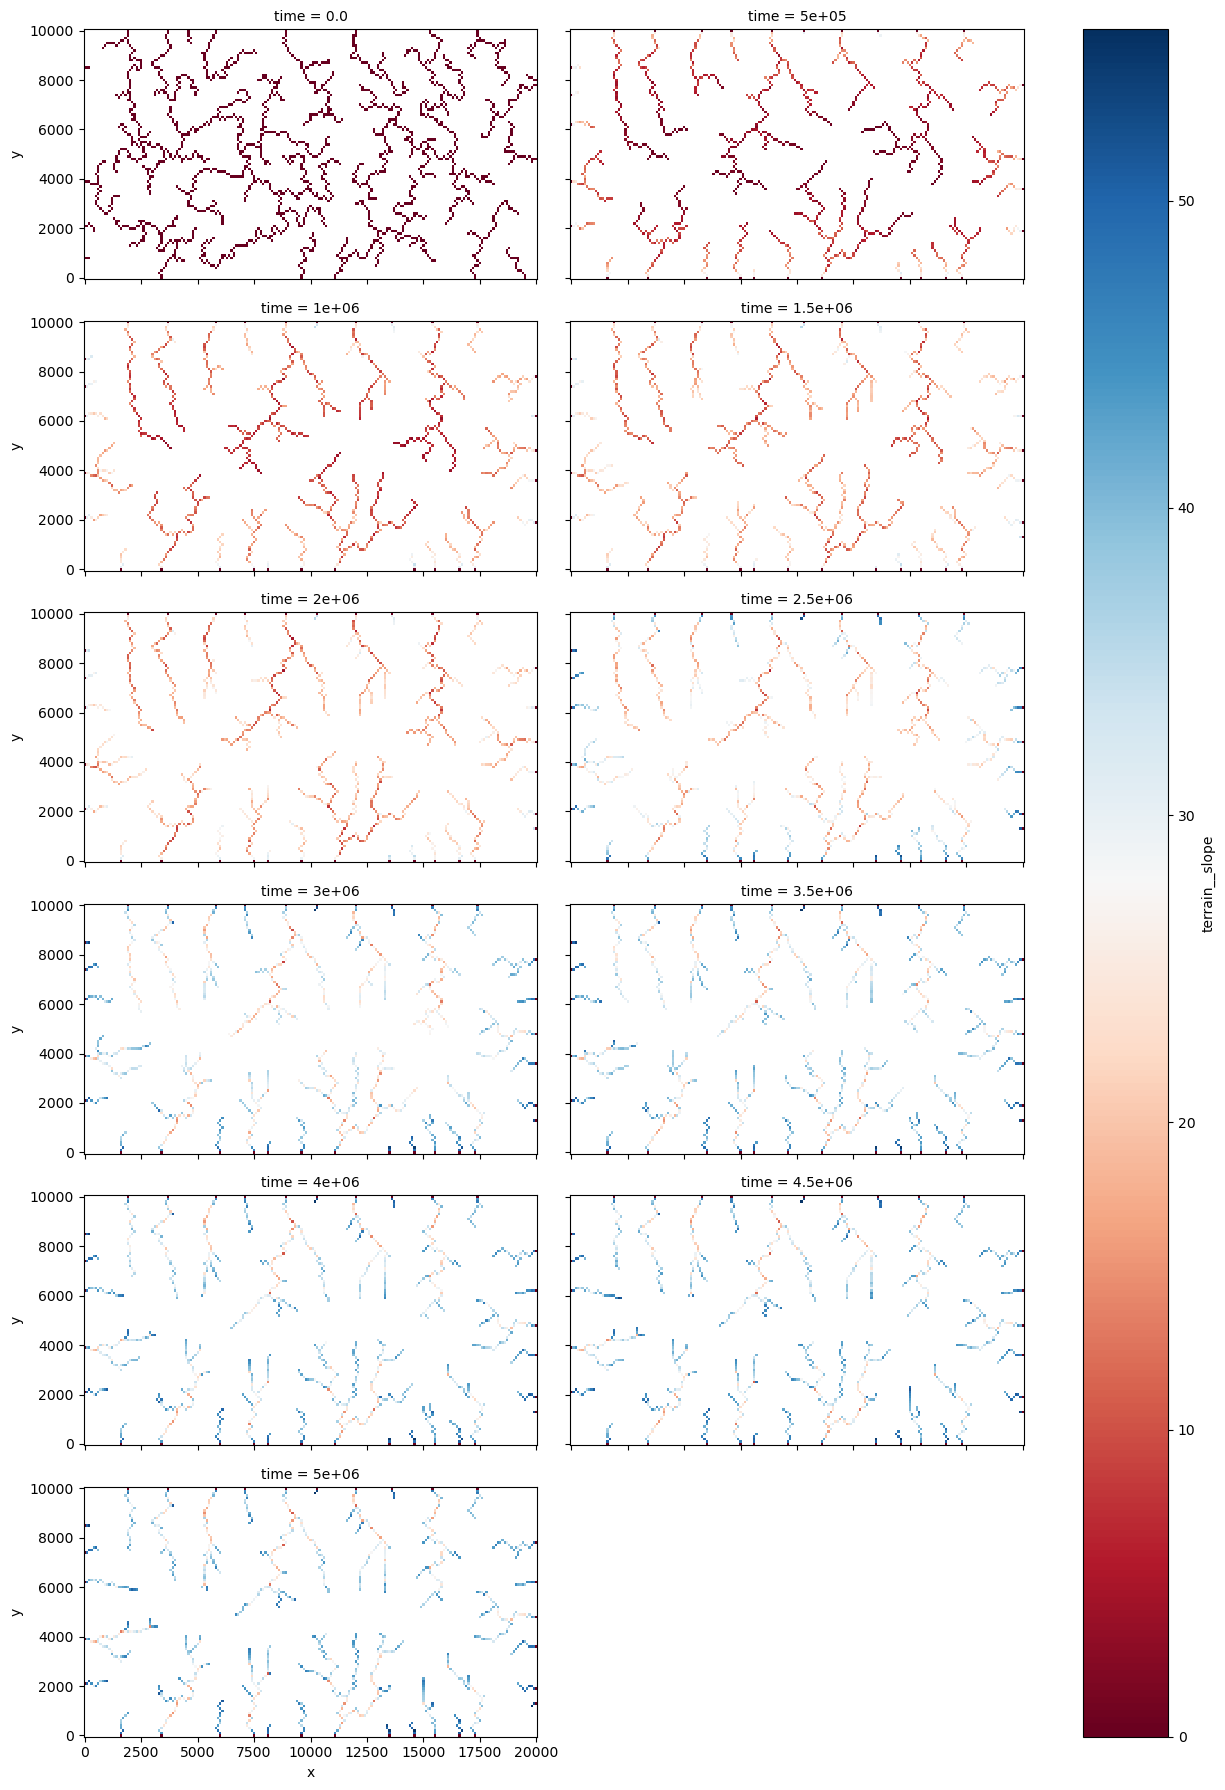

In [10]:
(ds_out.terrain__slope
 .where(ds_out.drainage__area>ds_out.drainage__area.max()/100)
 .sel(time=ds_out.time[::10])
 .plot(col='time', col_wrap=2, aspect=2, cmap='RdBu')
 )